In [29]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Rescaling, Resizing
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomFlip 
from tensorflow.keras.layers import RandomContrast
from tensorflow.keras.layers import RandomBrightness
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import numpy as np

In [30]:
(datos_train, datos_val) = image_dataset_from_directory(
    "./viajes",
    labels= "inferred",
    label_mode = "categorical",
    class_names = ["Montaña", "Playa"],
    image_size = (150,150),
    shuffle= True,
    seed = 10,
    validation_split = 0.3,
    subset = "both",
    crop_to_aspect_ratio = False
)

Found 200 files belonging to 2 classes.
Using 140 files for training.
Using 60 files for validation.


In [31]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2

#Creamos un modelo con la base de MobileNetV2
modelo_mobilenet = MobileNetV2(weights="imagenet", include_top= False, input_shape=(150,150,3))

C:\Users\David\AppData\Local\Temp\ipykernel_16088\485103267.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  modelo_mobilenet = MobileNetV2(weights="imagenet", include_top= False, input_shape=(150,150,3))


In [32]:
#Vamos a sacar el resumen para ver sus capas
modelo_mobilenet.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [33]:
#Creamos un modelo de aumentación de datos
modelo_aumentacion = Sequential()
modelo_aumentacion.add(RandomFlip(mode='horizontal'))
modelo_aumentacion.add(RandomTranslation(0.1, 0.1))
modelo_aumentacion.add(RandomRotation((-0.1, +0.1), fill_mode = 'reflect'))
modelo_aumentacion.add(RandomZoom((-0.05, 0.05)))
#modelo_aumentacion.add(RandomBrightness((-0.2, +0.2), value_range=(0, 1)))
#modelo_aumentacion.add(RandomContrast(0.2))

In [34]:
#Creamos el modelo final 
modelo_final = Sequential()
modelo_final.add(Rescaling(1./255, input_shape=(150,150,3)))
modelo_final.add(Resizing(150,150))

#Añadimos el modelo de aumentación y el de mobilenet
modelo_final.add(modelo_aumentacion)
modelo_final.add(modelo_mobilenet)

#Clasificador
modelo_final.add(GlobalAveragePooling2D())
modelo_final.add(Dense(128, activation="relu", kernel_initializer="he_uniform"))
modelo_final.add(Dense(64,activation="relu"))
modelo_final.add(Dropout(0.2))
modelo_final.add(Dense(2, activation="softmax"))

modelo_final.summary()

c:\Users\David\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_2 (Resizing)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,338 (9.27 MB)

 Trainable params: 2,396,226 (9.14 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [35]:
print(modelo_mobilenet.input_shape)                                                         
print(modelo_mobilenet.output_shape)

(None, 150, 150, 3)
(None, 5, 5, 1280)


In [36]:
#Congelamos las capas para que no entrenen
for capa in modelo_mobilenet.layers:
    capa.trainable=False

In [37]:
import tensorflow as tf
modelo_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
h = modelo_final.fit(
    datos_train,
    validation_data = datos_val,
    epochs = 15,
    verbose=True
)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 602ms/step - accuracy: 0.4929 - loss: 1.0325 - val_accuracy: 0.8000 - val_loss: 0.4273
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - accuracy: 0.7357 - loss: 0.4667 - val_accuracy: 0.9000 - val_loss: 0.2722
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - accuracy: 0.8429 - loss: 0.3755 - val_accuracy: 0.9500 - val_loss: 0.1443
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step - accuracy: 0.8571 - loss: 0.3124 - val_accuracy: 0.9500 - val_loss: 0.1334
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 274ms/step - accuracy: 0.8857 - loss: 0.2790 - val_accuracy: 0.9667 - val_loss: 0.1787
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step - accuracy: 0.9071 - loss: 0.2591 - val_accuracy: 0.9500 - val_loss: 0.1352
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.9429 - loss: 0.1726 - val_accuracy: 0.9500 - val_loss: 0.1340
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - accuracy: 0.9357 - loss: 0.2056 - val_accuracy: 0.9667 - val_loss:

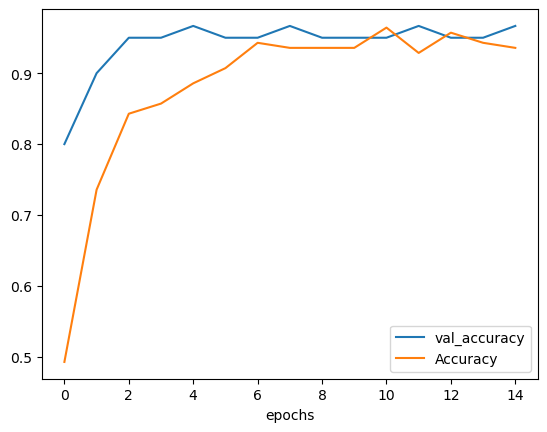

In [39]:
accuracy = h.history['accuracy']
val_accuracy = h.history['val_accuracy']
n_epochs = len(accuracy)
plt.plot(range(0, n_epochs), val_accuracy, label='val_accuracy')
plt.plot(range(0, n_epochs), accuracy, label='Accuracy')
plt.xlabel('epochs')
plt.legend()

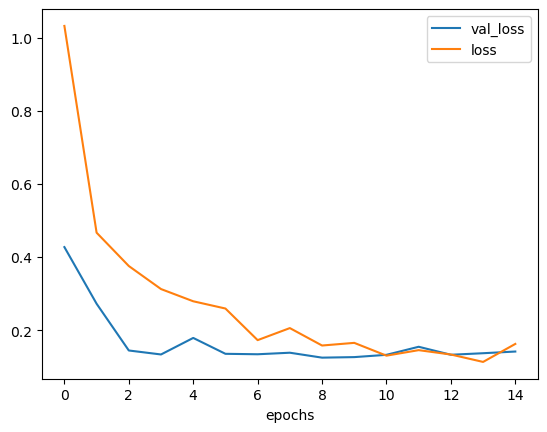

In [40]:
loss = h.history['loss']
val_loss = h.history['val_loss']
n_epochs = len(loss)
plt.plot(range(0, n_epochs), val_loss, label='val_loss')
plt.plot(range(0, n_epochs), loss, label='loss')
plt.xlabel('epochs')
plt.legend()

In [41]:
test_loss, test_acc = modelo_final.evaluate(datos_val)
print("Test loss", test_loss)
print("Test accuracy", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9667 - loss: 0.1414
Test loss 0.14143402874469757
Test accuracy 0.9666666388511658


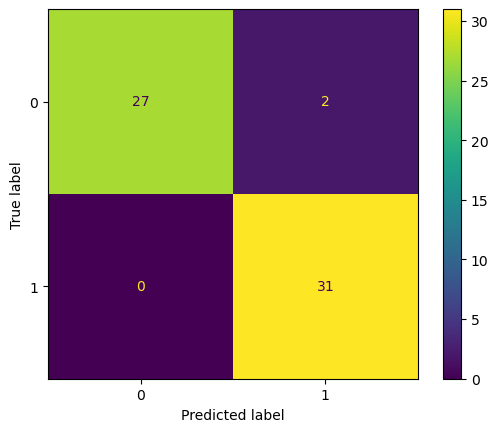

In [42]:
# Obtener todas las etiquetas reales del dataset de validación
y_true = []
for batch in datos_val:
    labels = batch[1].numpy()
    y_true.extend(np.argmax(labels, axis=1))

# Hacer predicciones sobre el dataset de validación
y_pred = []
for batch in datos_val:
    preds = modelo_final.predict(batch[0], verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

# Matriz de confusión
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)
mcd = ConfusionMatrixDisplay(cm)
mcd.plot()

In [43]:
modelo_final.save("modelo_viajes.keras")